# Experiment notebook

In [1]:
# Basic functionality
from datetime import datetime

# Plotting and visualization
# Garmin specific imports
from utils.garmin_aux import clean, details_to_df, init_garmin_api
from utils.plotting_aux import plot_activity, plot_activity_calendar

## Garmin API

In [2]:
g_api = init_garmin_api()

if g_api is None:
    raise RuntimeError("No se pudo inicializar la API de Garmin")

# We get the total number of activities
total_activities = g_api.count_activities()

# We extract all logged garmin activities
activities = []
for i in range(
    0, total_activities, 1000
):  # The api can only return 1000 activities at a time so we import by batches
    batch = g_api.get_activities(i, 1000)
    if not batch:
        break
    activities.extend(batch)

We plot all days with activities

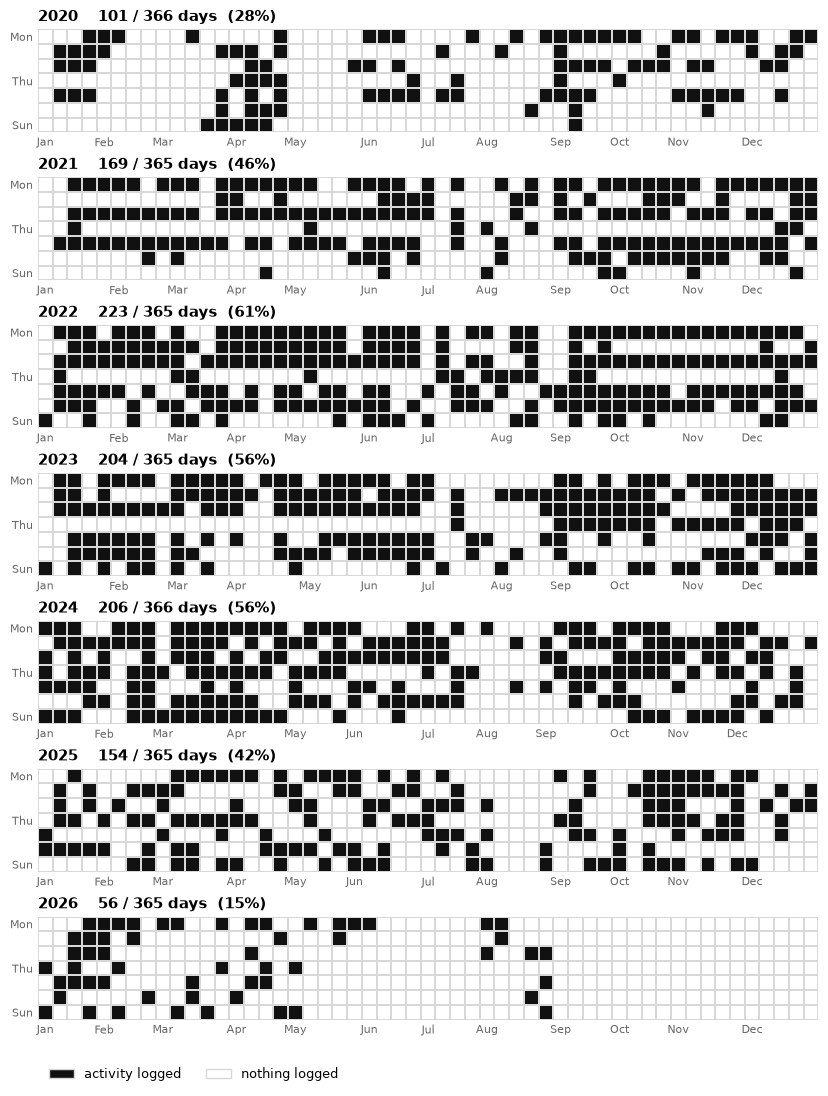

In [3]:
dates = [datetime.fromisoformat(a["startTimeLocal"]).date() for a in activities]
plot_activity_calendar(dates);

Now we want to analize a given activity, for example, the last activity returning all possible data.

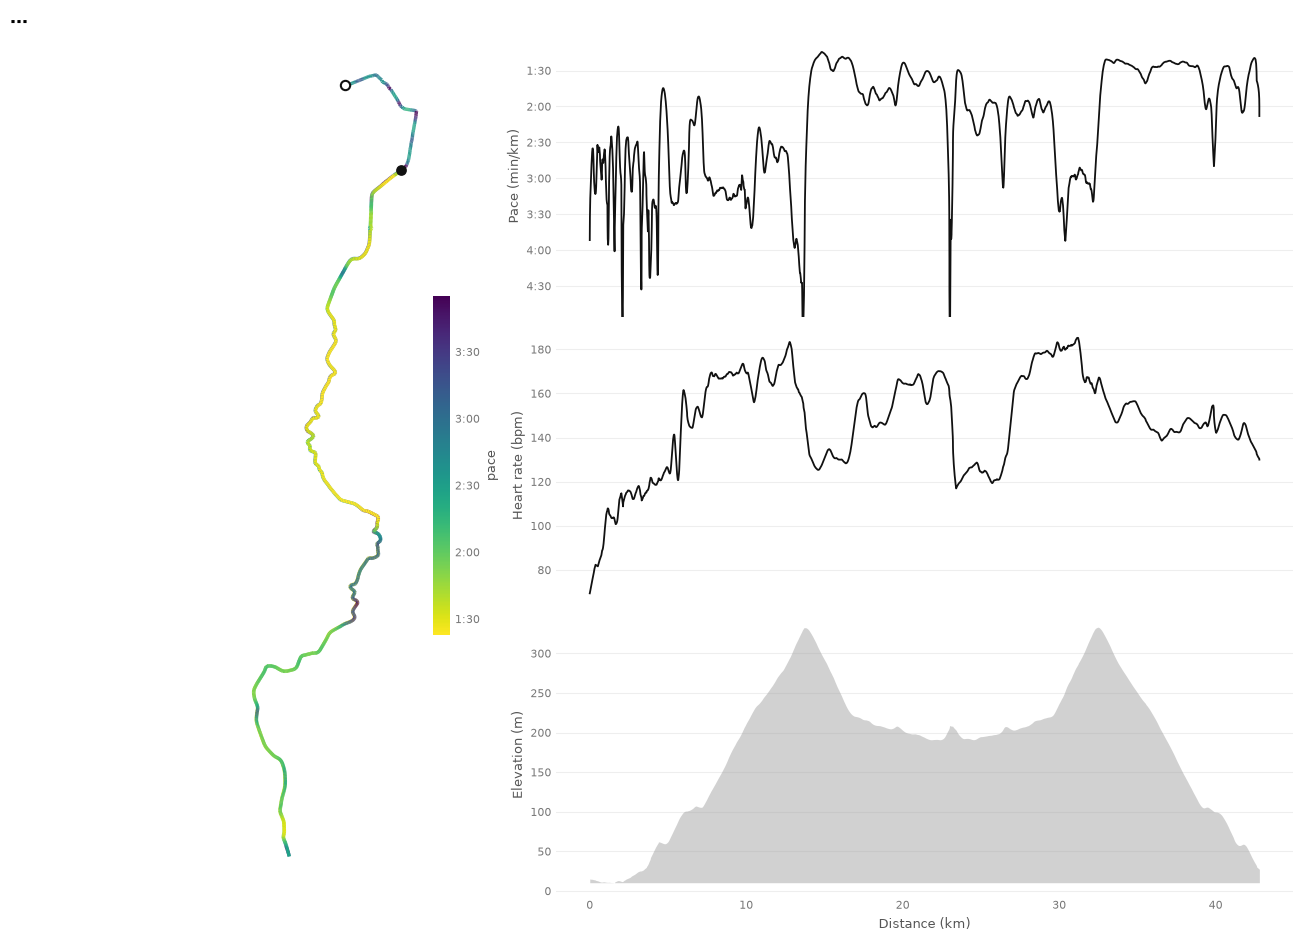

In [4]:
last_activity_id = activities[0]["activityId"]
last_activity_details = g_api.get_activity_details(last_activity_id)

df = clean(details_to_df(last_activity_details))
plot_activity(df, title="…");

Now that I can access every activity, it would ake sense to create a db with all this info.